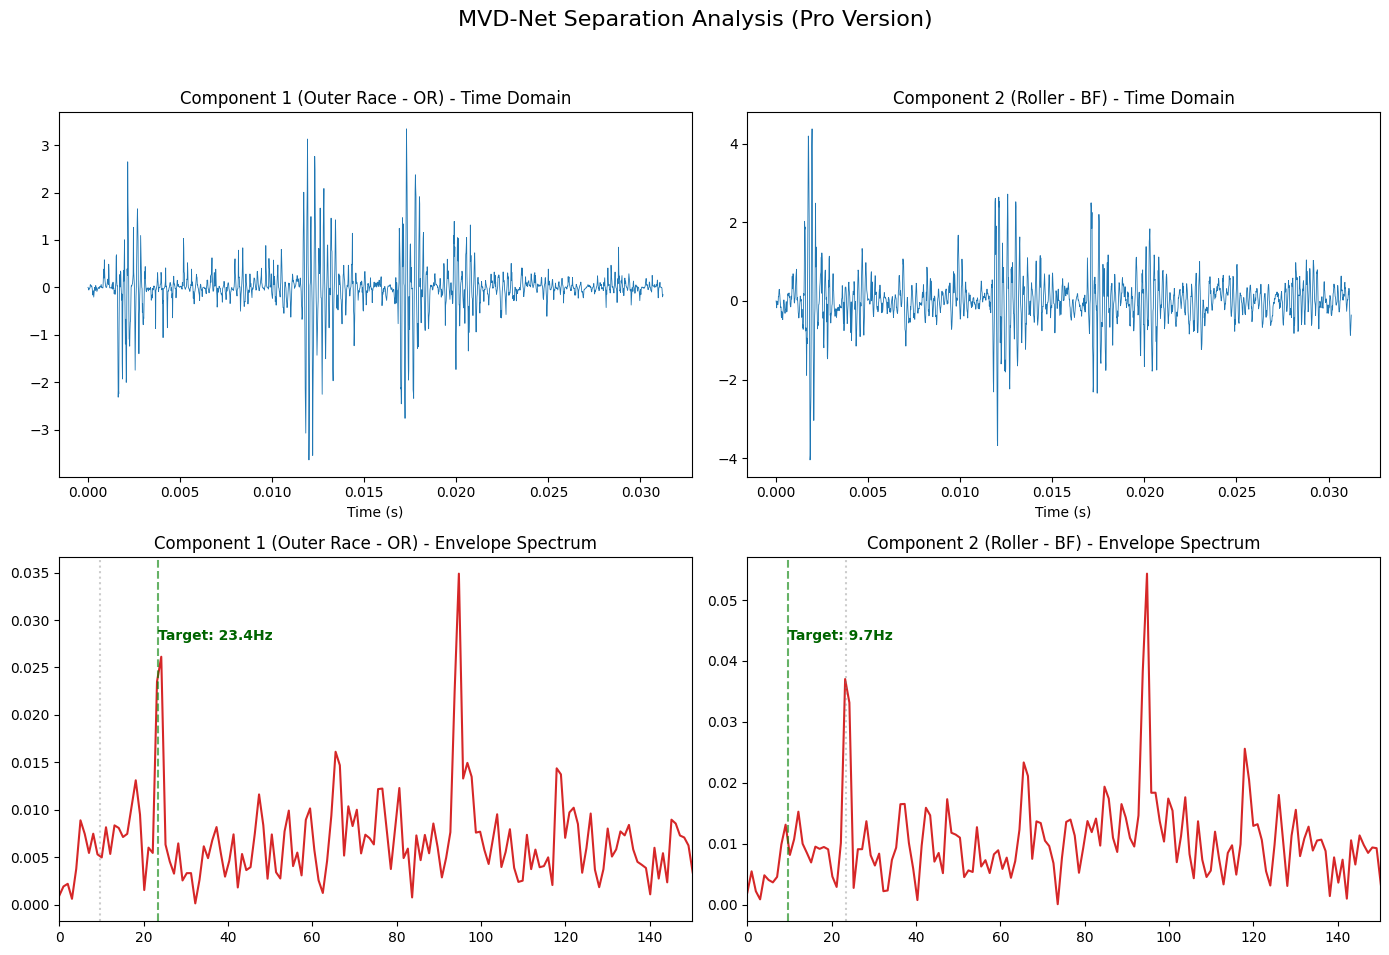

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.signal import hilbert, butter, filtfilt, windows
from model import MVDNet

# ==========================================
# 1. 专家级信号处理函数
# ==========================================
def get_env_spec(sig, fs=64000):
    """
    带通滤波 + 希尔伯特变换 + 汉宁窗 + rfft
    """
    nyq = 0.5 * fs
    # 采用论文推荐的高频共振频带
    b, a = butter(4, [2000/nyq, 20000/nyq], btype='band')
    f_sig = filtfilt(b, a, sig)
    
    # 提取包络并加窗
    env = np.abs(hilbert(f_sig))
    env = (env - np.mean(env)) * windows.hann(len(env))
    
    freqs = np.fft.rfftfreq(len(env), 1/fs)
    spec = np.abs(np.fft.rfft(env)) / len(env)
    return freqs, spec

# ==========================================
# 2. 推理引擎：重叠相加法 (OLA)
# ==========================================
def separate_ola(model, sig, device):
    """
    50% 重叠滑窗推理，消除拼接处的相位跳变
    """
    model.eval()
    L, chunk, overlap = len(sig), model.input_len, 0.5
    stride = int(chunk * (1 - overlap))
    sep_bufs = [np.zeros(L) for _ in range(model.K)]
    weight_buf = np.zeros(L)
    win = np.hanning(chunk)

    with torch.no_grad():
        for s in range(0, L - chunk + 1, stride):
            e = s + chunk
            # 局部归一化
            x_chunk = sig[s:e]
            norm_x = (x_chunk - np.mean(x_chunk)) / (np.std(x_chunk) + 1e-8)
            x_tensor = torch.tensor(norm_x, dtype=torch.float32).view(1, 1, -1).to(device)
            
            # 调用 model.py 中的 Mask 分离接口
            out = model.get_mask_separation(x_tensor)
            for k in range(model.K):
                sep_bufs[k][s:e] += out[k].cpu().numpy().flatten() * win
            weight_buf[s:e] += win
            
    return [b / (weight_buf + 1e-8) for b in sep_bufs]

# ==========================================
# 3. 绘图与标注主程序
# ==========================================
def run_test(data_root, model_path="mvd_net_final.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MVDNet(K=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    # 读取复合故障数据 (Task A: LA2+LA3)
    path = os.path.join(data_root, 'M0_G0_LA2+LA3_RA0', 'Sample_1')
    file = [f for f in os.listdir(path) if "20Hz_0kN" in f and "leftaxlebox" in f][0]
    raw_sig = pd.read_csv(os.path.join(path, file))['CH17'].values[:63488]
    
    # 执行分离
    seps = separate_ola(model, raw_sig, device)
    
    # 【核心修改：精确标注 BF 与 OR】
    # 通道 0 对应 LA2 -> OR (23.4Hz)
    # 通道 1 对应 LA3 -> BF (9.7Hz)
    titles = ["Component 1 (Outer Race - OR)", "Component 2 (Roller - BF)"]
    fcf_list = [23.4, 9.7] 

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for k in range(2):
        freqs, spec = get_env_spec(seps[k])
        
        # 第一行：分离后的时域波形 (局部展示)
        axes[0, k].plot(np.arange(2000)/64000, seps[k][:2000], lw=0.6)
        axes[0, k].set_title(f"{titles[k]} - Time Domain")
        axes[0, k].set_xlabel("Time (s)")
        
        # 第二行：包络谱
        axes[1, k].plot(freqs, spec, color='tab:red')
        axes[1, k].set_xlim(0, 150)
        axes[1, k].set_title(f"{titles[k]} - Envelope Spectrum")
        
        # 标注目标特征频率
        target_f = fcf_list[k]
        axes[1, k].axvline(target_f, color='green', ls='--', alpha=0.6)
        axes[1, k].annotate(f'Target: {target_f}Hz', 
                            xy=(target_f, np.max(spec)*0.8), 
                            color='darkgreen', weight='bold', fontsize=10)
        
        # 标注干扰频率 (另一通道的目标频率) 以观察抑制效果
        inter_f = fcf_list[1-k]
        axes[1, k].axvline(inter_f, color='gray', ls=':', alpha=0.4)

    plt.suptitle("MVD-Net Separation Analysis (Pro Version)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 自动保存
    os.makedirs("separation_results", exist_ok=True)
    plt.savefig("separation_results/pro_separation_labeled.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    DATA_PATH = r"E:\BaiduNetdiskDownload\BJTU-RAO Bogie Datasets\Data\BJTU_RAO_Bogie_Datasets\BJTU_RAO_Bogie_Datasets"
    run_test(DATA_PATH)